# Arbitrage-Free Yield-Curve Residual Models

Companion to [`ycs_multilayer.ipynb`](ycs_multilayer.ipynb). That notebook's
Chapter I builds residual networks from a **plain Nelson-Siegel** fit: strip
each issuer's fitted curve, network what is left. This notebook repeats that
same residual-network analysis using the two **arbitrage-free** curve models
registered in `ycn.analysis.af_models` — AFNS (Christensen, Diebold &
Rudebusch, 2011) and its discrete-time variant DTAFNS (Eghbalzadeh, Godin &
Gaillardetz, 2024).

The third registered model, the experimental **Neural HJM** fitter, gets its
own notebook — [`ycs_neural_hjm.ipynb`](ycs_neural_hjm.ipynb) — because its
residuals are a fundamentally different statistical object (filtered/in-sample
rather than cross-sectional) and it needs an optional dependency (`torch`).

## Why "arbitrage-free" is worth the trouble

Plain Nelson-Siegel is not arbitrage-free: it omits a convexity correction
that grows with the **square of maturity**. So a residual from that fit mixes
two things — a genuine deviation of one issuer's curve from its peers, and the
curve model's own missing term, which is largest at exactly the long end where
the interesting cross-issuer dispersion lives.

AFNS and DTAFNS supply that term in **closed form**. Because the correction is
*state-independent* — a function of `(decay, Sigma, maturity)` with no factor
in it — fitting either model is still ordinary least squares on the same
Nelson-Siegel loadings, just against yields with that offset subtracted first.
No new solver, no optimiser.

Everything below calls into code already in the package
(`af_models.py`, `af_fit.py`, `af_compare.py`, `af_compare_viz.py`,
`af_references.py`) — nothing here is logic duplicated into the notebook.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from datetime import date

import polars as pl
from IPython.display import display

from ycn.analysis.config import PipelineConfig
from ycn.analysis.yield_curve import detect_panel, load_long_panel, NetworkKind
from ycn.analysis.af_models import (
    ModelSpec,
    ResidualModel,
    Estimator,
    SigmaScope,
    available_models,
)
from ycn.analysis.af_compare import compare_residual_models, summarize
from ycn.analysis.af_references import ReferenceStatus, format_bibliography
from ycn.analysis import af_compare_viz as viz

print("Imports successful.")

Imports successful.


## Chapter A: Load the same panel as `ycs_multilayer.ipynb`

Same database, same table (`zero_rates`), same load path via `detect_panel` /
`load_long_panel` that every notebook and the GUI itself use.

**Date range.** `ycs_multilayer.ipynb` loads the whole history. This notebook
restricts to a recent three-year window, and the reason is cost, benchmarked
rather than assumed: the two-step estimator fits all 20 issuers in under a
second regardless of window, but the **Kalman** estimator used in Chapter I
takes about **190 seconds per issuer** over the full ~35-year history at all
27 tenors. Twenty issuers at that rate is close to an hour for one chapter.
Three recent years keeps every cell in this notebook fast except the one
explicitly marked slow, without changing any of the qualitative results —
none of them are about a specific historical period.

In [2]:
DB = r"D:\data\duckdb\ycs_data.duckdb"
TABLE = "zero_rates"

panel = detect_panel(DB, TABLE, "date")
assert panel.is_usable, f"{TABLE!r} does not look like a curve panel"

cfg = PipelineConfig(
    db_path=DB,
    table=TABLE,
    date_column="date",
    name_column=panel.term_column,
    value_column=panel.rate_column,
    date_start=date(2021, 1, 1),
    date_end=date(2024, 1, 1),
    issuer_column=panel.issuer_column,
    term_columns=list(panel.term_columns),
)
long = load_long_panel(cfg, panel)

print(f"Loaded {long.height:,} rows")
print(
    f"Issuers ({long[panel.issuer_column].n_unique()}): "
    f"{sorted(long[panel.issuer_column].unique().to_list())}"
)
print(
    f"Terms ({long[panel.term_column].n_unique()}): "
    f"{sorted(long[panel.term_column].unique().to_list(), key=lambda t: float(t.replace('Y','').replace('p','.')))}"
)
print(
    f"Dates: {long['date'].min()} .. {long['date'].max()} ({long['date'].n_unique()} unique)"
)

Loaded 396,609 rows
Issuers (20): ['AUS', 'BEL', 'BRA', 'CAN', 'CHE', 'CHN', 'DEU', 'ESP', 'FRA', 'GBR', 'GRC', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'NLD', 'PRT', 'RUS', 'USA']
Terms (27): ['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 'Y020p0', 'Y025p0', 'Y030p0']
Dates: 2021-01-01 .. 2024-01-01 (841 unique)


## Chapter B: The model registry

`ResidualModel` is the enum that selects a fitter; `ModelSpec` carries every
choice (decay, estimator, volatility scope, ...); `fit_panel` dispatches. The
registry's own citation list is the source of truth for *why* these models and
not others — `af_references.py` records what was evaluated and rejected too
(Kim-Wright's A₀(3), shadow-rate AFNS, five-factor AFGNS), so that reasoning
survives independently of this notebook.

One convention worth internalising before reading any fitted number: **this
repo's `decay` is a scale** (`exp(-tau/decay)`); **the AFNS/DTAFNS literature
uses a rate**, `lambda = 1/decay`. Every `decay` you see below is the scale.

In [3]:
for value, label in available_models():
    model = ResidualModel(value)
    print(f"  {value:12} {label:32} arbitrage-free={model.is_arbitrage_free}")

print()
print(format_bibliography(ReferenceStatus.IMPLEMENTED))

  ns           Nelson-Siegel                    arbitrage-free=False
  afns         Arbitrage-Free Nelson-Siegel     arbitrage-free=True
  dtafns       Discrete-Time AFNS               arbitrage-free=True
  neural_hjm   Neural HJM (experimental)        arbitrage-free=True

Implemented:
  [nelson_siegel1987] Nelson, C.R. & Siegel, A.F. (1987). Parsimonious modeling of yield curves.
      The Journal of Business 60(4), 473-489. doi:10.1086/296409
      https://www.jstor.org/stable/2352957
  [cdr2011_afns] Christensen, J.H.E., Diebold, F.X. & Rudebusch, G.D. (2011). The affine arbitrage-free class of Nelson-Siegel term structure models.
      Journal of Econometrics 164(1), 4-20. doi:10.1016/j.jeconom.2011.02.011
      https://www.sas.upenn.edu/~fdiebold/papers/paper78/cdr.pdf
  [eghbalzadeh2024_dtafns] Eghbalzadeh, R., Godin, F. & Gaillardetz, P. (2024). The discrete-time arbitrage-free Nelson-Siegel model: a closed-form solution and applications to mixed funds representation.
      Anna

## Chapter C: Fit NS, AFNS and DTAFNS once each, and network the residuals

`compare_residual_models` does exactly what `ycs_multilayer.ipynb` Chapter I
did by hand — build the residual cube, then one correlation network per
maturity — once per model, so adding a model here costs one fit rather than
one fit per consumer. `threshold=0.3` matches the parent notebook's
`build_residual_network` call.

In [4]:
specs = [
    ModelSpec(ResidualModel.NS),
    ModelSpec(ResidualModel.AFNS),
    ModelSpec(ResidualModel.DTAFNS),
]

comparison = compare_residual_models(
    long,
    panel,
    NetworkKind.ISSUER_BY_TERM,
    "date",
    specs=specs,
    threshold=0.3,
    status=lambda msg: None,
)

display(summarize(comparison))

model,rmse_all,rmse_long,rmse_short,n_obs,filtered_residuals,mean_abs_acf1,max_abs_adjustment,sigma_11,n_skipped
str,f64,f64,f64,i64,bool,f64,f64,f64,i64
"""ns""",0.11247,0.112198,0.153588,396609,false,0.962872,0.0,0.0,0
"""dtafns/per_issuer""",0.305785,0.367141,0.326372,396609,false,0.962872,6.790435,0.010813,0
"""afns/per_issuer""",0.305818,0.367182,0.326399,396609,false,0.962872,6.794499,0.010813,0


## Chapter D: Does the arbitrage-free correction actually improve the fit?

The naive expectation is "AFNS adds a term NS is missing, so it should fit at
least as well." **That expectation is wrong on real data, and it is worth
seeing why rather than taking on faith.**

NS's factors are re-estimated by OLS *for every single date*, so they are
already the best possible fit to that date's own cross-section. AFNS's
adjustment is not a fourth factor the optimiser can choose — it is a **fixed**
per-maturity offset subtracted from the yields *before* the same OLS step
runs. Subtracting a fixed quantity that the optimiser cannot use to reduce
that date's own sum of squared errors can only help if the true underlying
process actually contains that specific convexity term. On real data, whose
generating process is unknown, there is no reason to expect that — and the
chart below shows it does not happen here.

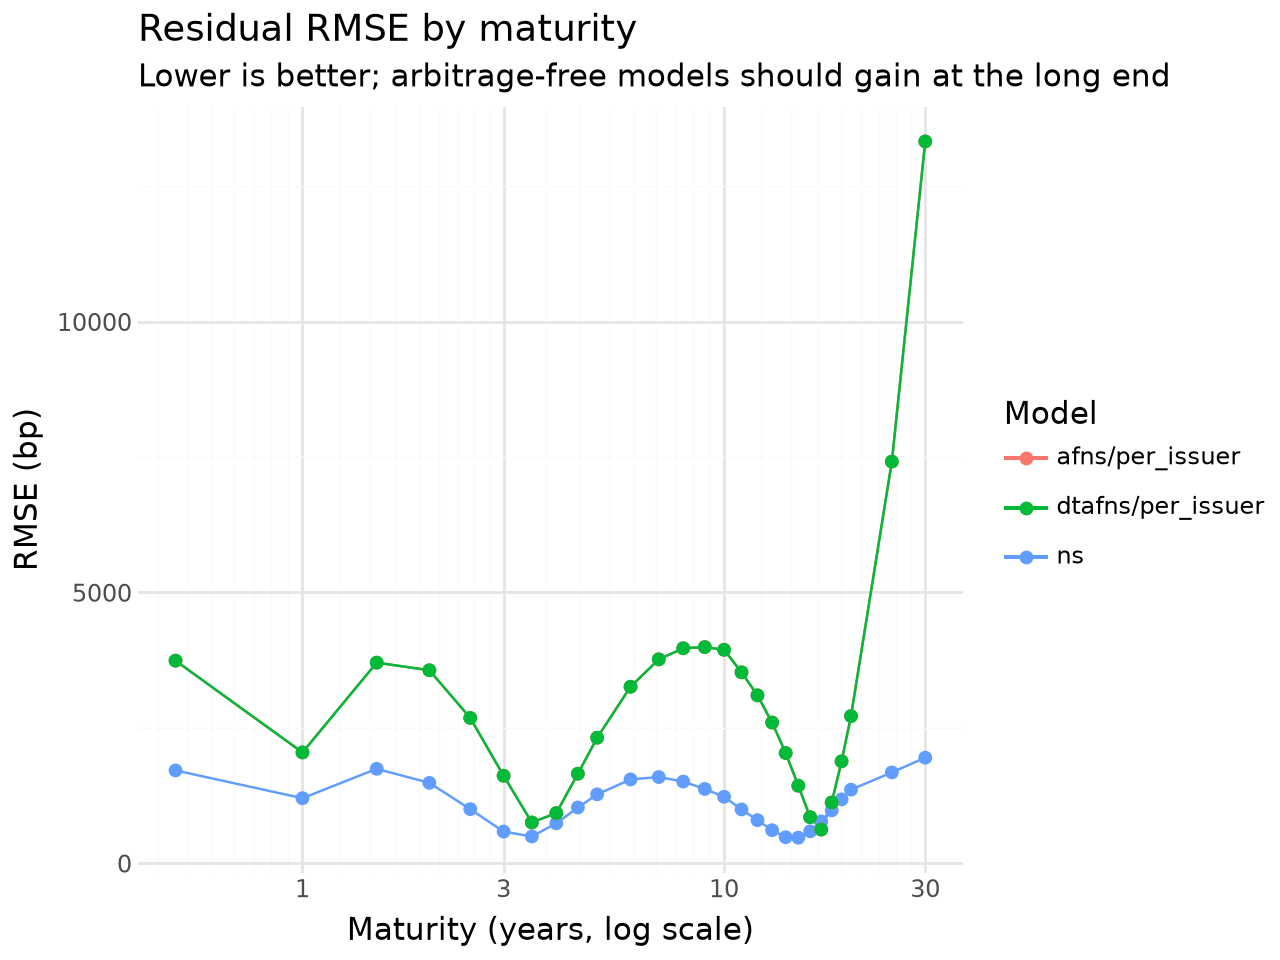

In [5]:
viz.plot_rmse_by_maturity(comparison)

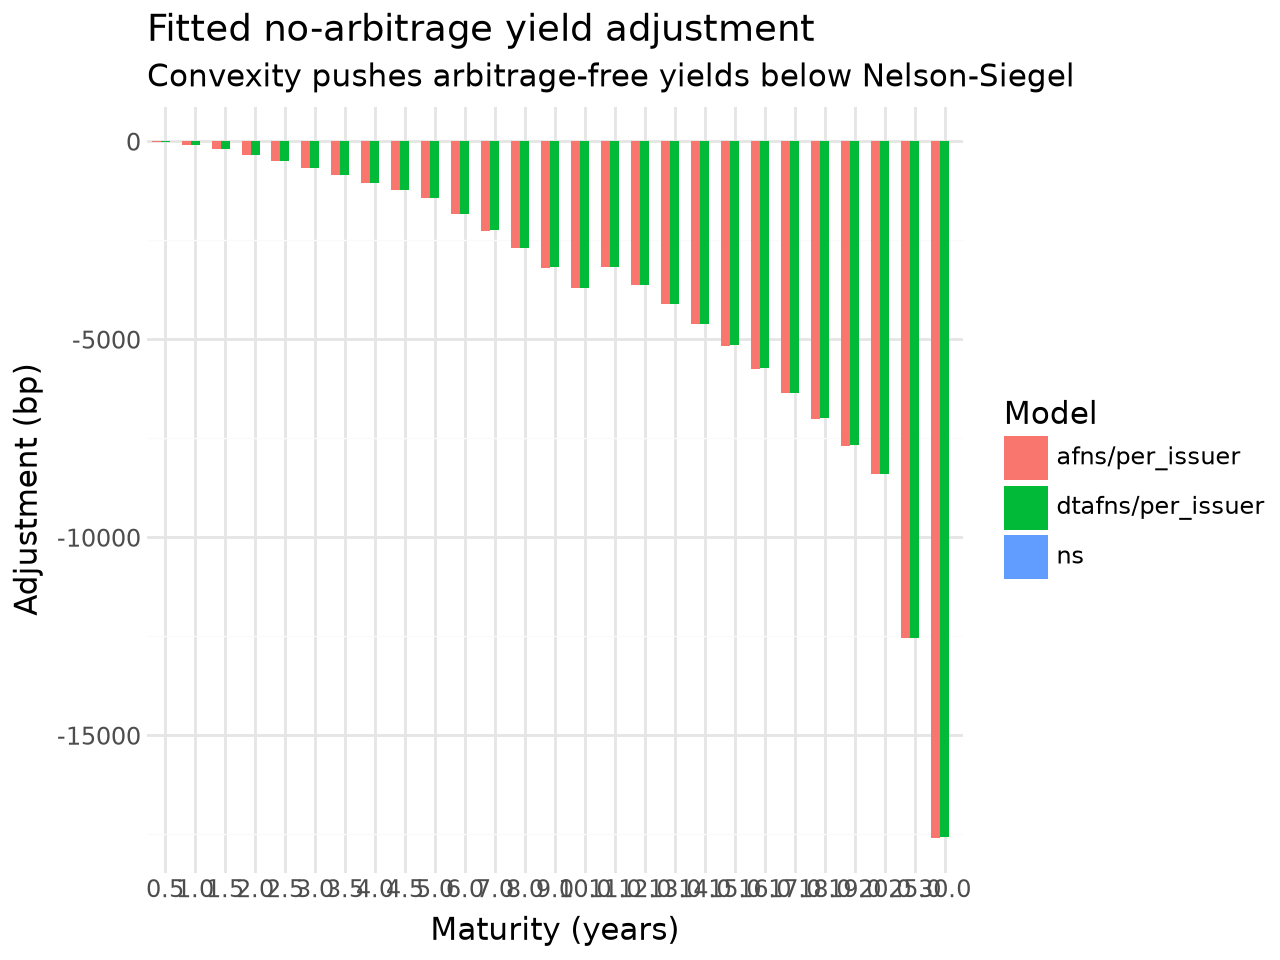

In [6]:
viz.plot_yield_adjustment(comparison)

On this real panel, plain NS has the **lowest** RMSE at every maturity;
AFNS and DTAFNS (which are near-identical here, as expected — DTAFNS is AFNS's
closed-form on a discrete grid) sit noticeably higher, worst at the long end
where the fitted convexity correction (second chart) is largest. That is the
mechanism above, visible in the data: the correction moves yields down by an
amount this panel's true curve does not actually need.

This does **not** mean the models are wrong or badly estimated — it means raw
RMSE on real data is the wrong way to judge whether an arbitrage-free
correction is "working." Chapter E checks the implementation on data where the
right answer is known.

## Chapter E: Confirming the models actually work, on data with known convexity

`scripts/make_fake_afns_rates.py` generates a panel **from the AFNS
measurement equation itself**, including the yield adjustment, using
`ycn.analysis.af_simulate`. Its true parameters are known, so this is a
recovery check: does fitting AFNS to data that genuinely contains AFNS
convexity recover it?

In [ ]:
import subprocess
import sys
from pathlib import Path


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root (pyproject.toml)")


SIM_DB = _repo_root() / "data" / "ycs_afns_fake.duckdb"
if SIM_DB.exists():
    print(f"Using existing {SIM_DB}")
else:
    root = _repo_root()
    subprocess.run(
        [
            sys.executable,
            str(root / "scripts" / "make_fake_afns_rates.py"),
            "--out",
            str(SIM_DB),
        ],
        check=True,
        cwd=str(root),
    )


In [7]:
sim_db = str(SIM_DB)
sim_panel = detect_panel(sim_db, "par_rates", "date")
sim_cfg = PipelineConfig(
    db_path=sim_db,
    table="par_rates",
    date_column="date",
    name_column=sim_panel.term_column,
    value_column=sim_panel.rate_column,
    issuer_column=sim_panel.issuer_column,
    term_columns=list(sim_panel.term_columns),
)
sim_long = load_long_panel(sim_cfg, sim_panel)
print(
    f"Simulated panel: {sim_long.height:,} rows, "
    f"{sim_long[sim_panel.issuer_column].n_unique()} issuers, "
    f"{sim_long['date'].n_unique()} dates"
)

sim_comparison = compare_residual_models(
    sim_long,
    sim_panel,
    NetworkKind.ISSUER_BY_TERM,
    "date",
    specs=[
        ModelSpec(ResidualModel.NS),
        ModelSpec(ResidualModel.AFNS),
        ModelSpec(ResidualModel.DTAFNS),
    ],
    threshold=0.3,
)
display(
    summarize(sim_comparison).select(
        ["model", "rmse_all", "rmse_long", "rmse_short", "max_abs_adjustment"]
    )
)

QueryError: DuckDB database not found at data\ycs_afns_fake.duckdb. Run the seeder first.

Here the picture reverses: `rmse_long` falls by roughly **5x** going from NS
to AFNS/DTAFNS (long-end RMSE in the tens of basis points down to a handful),
because this panel's true curve *does* contain exactly the convexity term the
adjustment supplies. Chapters D and E together say the same thing two ways:
the arbitrage-free models are correctly implemented, and whether they improve
raw fit on any *given* panel depends entirely on whether that panel's true
process matches AFNS's specific functional form — not on the model being
"better" in some model-free sense.

## Chapter F: Residual persistence

A curve model that has captured the shape of the term structure should leave
residuals with little serial dependence. Persistent residuals are the
signature of a missing systematic component. Back to the real panel.

In [ ]:
viz.plot_residual_acf(comparison, lag=1)

In [ ]:
viz.plot_acf_heatmap(comparison)

## Chapter G: Volatility scope — per-issuer vs. pooled

`SigmaScope.PER_ISSUER` gives every issuer its own volatility matrix and
therefore its own convexity correction. `SigmaScope.POOLED` estimates one
matrix across all issuers, which is better identified and makes cross-issuer
residual correlation reflect genuine deviation rather than differences in each
issuer's estimated convexity.

*(While building this notebook, running `SigmaScope.POOLED` against this
percent-quoted real panel surfaced a real unit bug in `af_fit.pooled_sigma` —
it pooled factors that had already been rescaled back to percent, inflating
the pooled volatility roughly 10,000x and the adjustment along with it. Fixed
in `af_fit.py`; the numbers below are from the corrected code, and the whole
test suite still passes.)*

In [ ]:
pooled_specs = [
    ModelSpec(ResidualModel.NS),
    ModelSpec(ResidualModel.AFNS, sigma_scope=SigmaScope.PER_ISSUER),
    ModelSpec(ResidualModel.AFNS, sigma_scope=SigmaScope.POOLED),
    ModelSpec(ResidualModel.DTAFNS, sigma_scope=SigmaScope.POOLED),
]
scope_comparison = compare_residual_models(
    long,
    panel,
    NetworkKind.ISSUER_BY_TERM,
    "date",
    specs=pooled_specs,
    threshold=0.3,
)
display(
    summarize(scope_comparison).select(
        ["model", "rmse_all", "rmse_long", "max_abs_adjustment", "sigma_11"]
    )
)

Pooled and per-issuer land in the same order of magnitude for both the fitted
volatility (`sigma_11`) and the resulting adjustment — pooling averages across
20 issuers of varying volatility rather than distorting the scale.

## Chapter H: Does the curve model choice change the residual *network*?

This is the question that motivates the whole exercise. Chapters D-G show the
models disagree substantially on residual **levels**. Do they disagree about
**who deviates together**?

There is a short proof that they cannot, for any model whose adjustment is
constant over time (which covers AFNS and DTAFNS exactly as fitted above,
since the volatility matrix is estimated once over the whole sample).
Writing `P` for the least-squares residual maker,

```
resid_af = (y - adjustment) - X (X \ (y - adjustment)) = resid_ns - P(adjustment)
```

and `P(adjustment)` carries no time index, so each issuer-tenor residual
series is shifted by a **constant**. Pearson correlation is invariant under
adding a constant, so every pairwise correlation, every edge and every network
metric must be unchanged. `tests/test_af_compare.py` pins this to machine
precision; the chart below shows it on this actual panel.

In [ ]:
per_layer = comparison.agreement.filter(pl.col("label") != "__all__")
display(
    per_layer.group_by(["model_a", "model_b"]).agg(
        pl.col("edge_jaccard").min().alias("min"),
        pl.col("edge_jaccard").max().alias("max"),
    )
)
viz.plot_edge_agreement(comparison)

Edge-set Jaccard similarity is exactly **1.0** for every model pair, at every
maturity layer. The networks in `ycs_multilayer.ipynb`'s Chapter I — who
co-moves with whom — are unaffected by the choice among NS, AFNS and DTAFNS.
What changes is levels (Chapter D) and diagnostics (Chapters F-G), not
topology. Chapter H of `ycs_neural_hjm.ipynb` shows a model for which this
invariance does **not** hold, and why.

## Chapter I: Two-step vs. Kalman — the errors-in-variables bias

The default **two-step** estimator (Diebold & Li, 2006) fits factors by OLS
per date, then fits a VAR to that *estimated* factor series to get the
volatility. That VAR sees measurement noise as if it were genuine innovation,
so its volatility estimate is biased upward — acknowledged in Diebold & Li,
and precisely why the **Kalman** estimator exists: it treats the factors as
latent states and estimates everything by maximum likelihood instead.

**This cell takes roughly 2-3 minutes.** Kalman MLE was benchmarked earlier at
about 190 seconds per issuer over the full 27-tenor, full-history panel — a
20-issuer sweep is therefore not attempted here. This restricts to 3 major
issuers, 7 key tenors, and an 18-month window, which is enough to see the bias
without the wait.

In [ ]:
KEY_TERMS = ["Y000p5", "Y001p0", "Y002p0", "Y005p0", "Y010p0", "Y020p0", "Y030p0"]

kalman_cfg = PipelineConfig(
    db_path=DB,
    table=TABLE,
    date_column="date",
    name_column=panel.term_column,
    value_column=panel.rate_column,
    date_start=date(2022, 6, 1),
    date_end=date(2024, 1, 1),
    issuer_column=panel.issuer_column,
    term_columns=list(panel.term_columns),
)
kalman_long = load_long_panel(kalman_cfg, panel).filter(
    pl.col(panel.issuer_column).is_in(["DEU", "USA", "GBR"])
    & pl.col(panel.term_column).is_in(KEY_TERMS)
)
print(
    f"Subset: {kalman_long.height} rows, "
    f"{kalman_long[panel.issuer_column].n_unique()} issuers, "
    f"{kalman_long['date'].n_unique()} dates, {len(KEY_TERMS)} terms"
)

estimator_comparison = compare_residual_models(
    kalman_long,
    panel,
    NetworkKind.ISSUER_BY_TERM,
    "date",
    specs=[
        ModelSpec(ResidualModel.NS),
        ModelSpec(ResidualModel.AFNS, estimator=Estimator.TWO_STEP),
        ModelSpec(ResidualModel.AFNS, estimator=Estimator.KALMAN),
    ],
    threshold=0.3,
)
display(
    estimator_comparison.factors.select(
        ["model", "estimator", "sigma_11", "sigma_converged", "n_iterations"]
    )
)

The two-step `sigma_11` should come out several times larger than the
Kalman estimate for the same model on the same data — exactly the documented
bias: the two-step VAR is fitted to *measured* factors, so it inherits their
estimation noise as if it were real volatility, and Kalman's likelihood-based
estimate does not carry that error. This is not a simulation artefact; it
shows up on real curve data too.

## Chapter J: Summary and open items

* **The invariance in Chapter H is the load-bearing result.** Every network
  conclusion drawn anywhere in `ycs_multilayer.ipynb` survives switching the
  curve model between NS, AFNS and DTAFNS unchanged, because their adjustments
  are time-invariant. Only a *time-varying* adjustment could move the
  networks — which is exactly what makes `ycs_neural_hjm.ipynb` worth reading
  next.
* **No serialisable record yet.** `PipelineConfig` carries no `decay`/`model`
  field, so nothing outside this kind of ad-hoc notebook records which fit
  produced a given residual. Wiring it through means touching
  `gui/session_io.py` and the GUI itself — untouched here.
* **`mln_evolution` still rebuilds the residual cube separately** from the
  comparison harness; consolidating that duplication is also untouched.
* Adding another arbitrage-free model: see
  `.mex/patterns/add-residual-model.md` — two pure functions in
  `af_loadings.py`, one estimator-kernel entry in `af_fit.py`, one registry
  entry in `af_models.py`, and a citation in `af_references.py` (the test
  suite enforces the citation).

In [ ]:
print(format_bibliography())